## Analysis of temporal patterns of toxicity and relationship with sentiment

**Goal:**  
- Test **Hypothesis 1**: Toxicity varies by day of week/hour.  
- Check **Hypothesis 2**: toxicity and sentiment (positive/negative) are related.  
- Prepare final conclusions and graphs for the report.

## Imports and settings

In [1]:
!pip install pyspark findspark scikit-posthocs -q

In [2]:
from pyspark.sql import SparkSession
spark = SparkSession.builder \
    .appName("FinalAnalysis") \
    .config("spark.sql.shuffle.partitions", "8") \
    .getOrCreate()
spark

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
from matplotlib.ticker import MultipleLocator
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/06/02 19:12:53 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Data

Get from previous notebook, where was markup of datasets

In [3]:
USER_FEAT_PATH = "/kaggle/input/notebooks/ksksksksksksksushka/markup-dataset/user_features.parquet"
TIME_FEAT_PATH = "/kaggle/input/notebooks/ksksksksksksksushka/markup-dataset/time_features.parquet"

user_features = spark.read.parquet(USER_FEAT_PATH)
time_features = spark.read.parquet(TIME_FEAT_PATH)

print("User features schema:")
user_features.printSchema()
print(f"Number of users: {user_features.count()}")
user_features.show(5, truncate=False)

print("\nTime features schema:")
time_features.printSchema()
time_features.show(5, truncate=False)

User features schema:
root
 |-- user: string (nullable = true)
 |-- tweet_count: long (nullable = true)
 |-- avg_toxicity: double (nullable = true)
 |-- toxic_ratio: double (nullable = true)
 |-- avg_sentiment_pos_ratio: double (nullable = true)

Number of users: 658713
+--------------+-----------+----------------------+-------------------+-----------------------+
|user          |tweet_count|avg_toxicity          |toxic_ratio        |avg_sentiment_pos_ratio|
+--------------+-----------+----------------------+-------------------+-----------------------+
|spacks        |2          |8.65967449499362E-5   |0.0                |0.0                    |
|ktribb80      |1          |0.0                   |0.0                |0.0                    |
|Hollywood_Trey|112        |0.08435814749207696   |0.08928571428571429|0.5982142857142857     |
|Augustina22CA |4          |4.306657171044337E-28 |0.0                |0.0                    |
|iCalvin       |7          |1.2690264072404433E-13|0.0   

We need to convert data to pandas for simplicity

In [4]:
time_pd = time_features.toPandas()
user_pd = user_features.toPandas()

# weekday from numberst to names
day_names = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
time_pd['day_name'] = time_pd['weekday'].map(day_names)

## Hypothesis 1: Toxicity depends on weekday and time?

Plan:

1. Create diagrams of avg toxicity (toxic_ratio) by days and hours
2. Add basic line (avg toxicity an a whole dataset)
3. Check statistical dependance

Results:

The data analysis showed that **the share of toxic tweets really depends on the day of the week and, to a lesser extent, on the time of day**.  
- There is a stable weekly cycle with a maximum on Tuesday and a minimum on Saturday.  
- During the day, toxicity increases slightly in the evening, reaching a peak around 21:00, and decreases in the early morning hours.  
- Statistical tests (ANOVA and Tukey HSD) confirm the significance of these differences for most days of the week and for individual hours.  

Thus, **the first hypothesis of the project is confirmed**: time factors (day of week, hour) have a statistically significant effect on the level of toxicity in tweets. This creates a basis for further study of the reasons for such patterns and for possible application in online communication monitoring systems.

In [5]:
# avg toxic rate

# numof toxic tweets at that time
time_pd['toxic_tweets'] = time_pd['total_tweets'] * time_pd['toxic_ratio']

# overal toxic rate = all TOXIC tweets at that time / all tweets at that time
overall_toxic_ratio = time_pd['toxic_tweets'].sum() / time_pd['total_tweets'].sum()
print(f"Overall mean toxic_ratio: {overall_toxic_ratio:.4f}")

Overall mean toxic_ratio: 0.0788


### Agregate by day

In [6]:

day_stats = time_pd.groupby('day_name')['toxic_ratio'].agg(['mean','std','count'])
day_stats['ci'] = 1.96 * day_stats['std'] / np.sqrt(day_stats['count'])  # 95% confidence interval
day_stats = day_stats.reset_index()

/tmp/ipykernel_16/2107389983.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=day_stats, x='day_name', y='mean', order=day_order, palette='plasma')


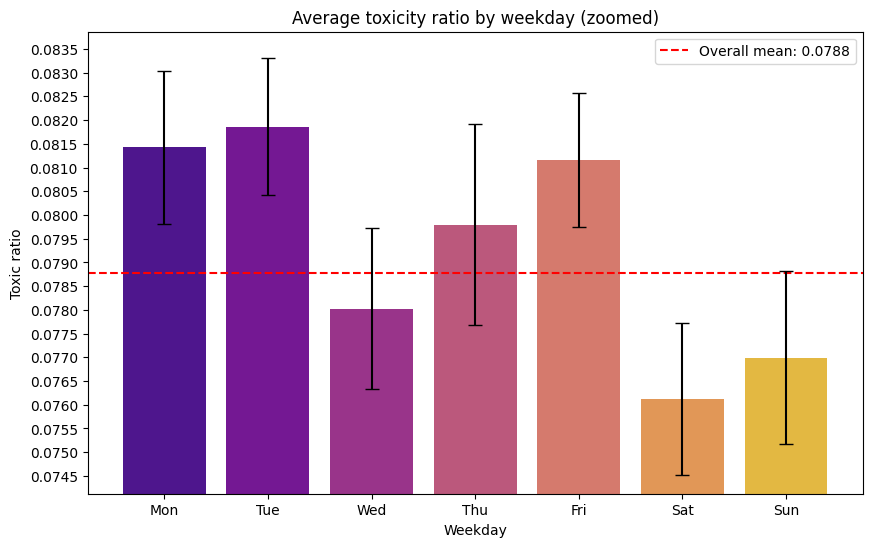

In [7]:
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_stats = day_stats.set_index('day_name').loc[day_order].reset_index()

plt.figure(figsize=(10,6))
ax = sns.barplot(data=day_stats, x='day_name', y='mean', order=day_order, palette='plasma')
plt.axhline(y=overall_toxic_ratio, color='red', linestyle='--', label=f'Overall mean: {overall_toxic_ratio:.4f}')
plt.errorbar(x=range(7), y=day_stats['mean'], yerr=day_stats['ci'], fmt='none', c='black', capsize=5)

ymin = day_stats['mean'].min() - 0.002
ymax = day_stats['mean'].max() + 0.002
plt.ylim(ymin, ymax)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.0005))

plt.title('Average toxicity ratio by weekday (zoomed)')
plt.xlabel('Weekday')
plt.ylabel('Toxic ratio')
plt.legend()
plt.show()

/tmp/ipykernel_16/4202292135.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=day_stats, x='day_name', y='diff_from_mean', palette=colors)


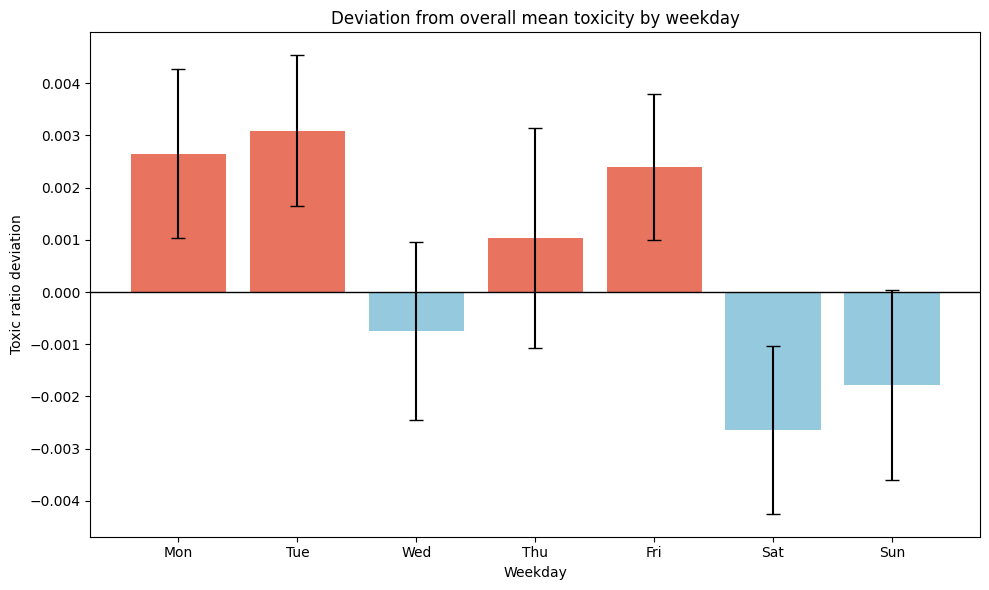

In [8]:
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
day_stats = day_stats.set_index('day_name').loc[day_order].reset_index()
day_stats['diff_from_mean'] = day_stats['mean'] - overall_toxic_ratio

plt.figure(figsize=(10,6))
colors = ['tomato' if diff > 0 else 'skyblue' for diff in day_stats['diff_from_mean']]
ax = sns.barplot(data=day_stats, x='day_name', y='diff_from_mean', palette=colors)
plt.axhline(y=0, color='black', linewidth=1)
plt.errorbar(x=range(7), y=day_stats['diff_from_mean'], yerr=day_stats['ci'], fmt='none', c='black', capsize=5)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.001))

plt.title('Deviation from overall mean toxicity by weekday')
plt.xlabel('Weekday')
plt.ylabel('Toxic ratio deviation')
plt.tight_layout()
plt.show()

What we can judge from that data?

- Toxicity differed markedly between days (we will check statistics by numbers later).  
- **The most toxic day is Tuesday**, and the **least toxic day is Saturday**.  
- The differences between neighboring days are not smooth: after the “peak” Tuesday there is a sharp decline on Wednesday, and after a rather toxic Friday there is a dip on Saturday.  
- Confidence intervals (black bars) confirm that the differences between Tuesday and Saturday, and between Tuesday and Sunday, are statistically reliable.  
- The plot of deviations from the overall average shows that Tuesday, Monday, Friday and Sunday have toxicity above the average for the dataset, and Saturday and Wednesday - below.

### Aggregate by hour

In [9]:
hour_stats = time_pd.groupby('hour')['toxic_ratio'].agg(['mean','std','count'])
hour_stats['ci'] = 1.96 * hour_stats['std'] / np.sqrt(hour_stats['count'])
hour_stats = hour_stats.reset_index()

/tmp/ipykernel_16/2251989326.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=hour_stats, x='hour', y='mean', palette = 'plasma')


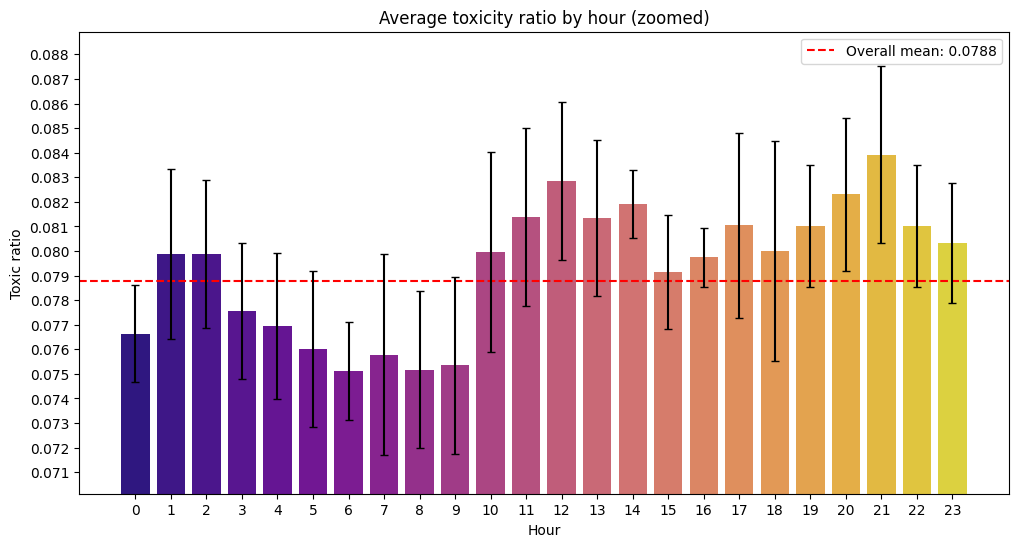

In [10]:
plt.figure(figsize=(12,6))
ax = sns.barplot(data=hour_stats, x='hour', y='mean', palette = 'plasma')
plt.axhline(y=overall_toxic_ratio, color='red', linestyle='--', label=f'Overall mean: {overall_toxic_ratio:.4f}')
plt.errorbar(x=range(24), y=hour_stats['mean'], yerr=hour_stats['ci'], fmt='none', c='black', capsize=3)

ymin = hour_stats['mean'].min() - 0.005
ymax = hour_stats['mean'].max() + 0.005
plt.ylim(ymin, ymax)

plt.gca().yaxis.set_major_locator(MultipleLocator(0.001))

plt.title('Average toxicity ratio by hour (zoomed)')
plt.xlabel('Hour')
plt.ylabel('Toxic ratio')
plt.legend()
plt.show()

/tmp/ipykernel_16/2969367510.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=hour_stats, x='hour', y='diff_from_mean', palette=colors)


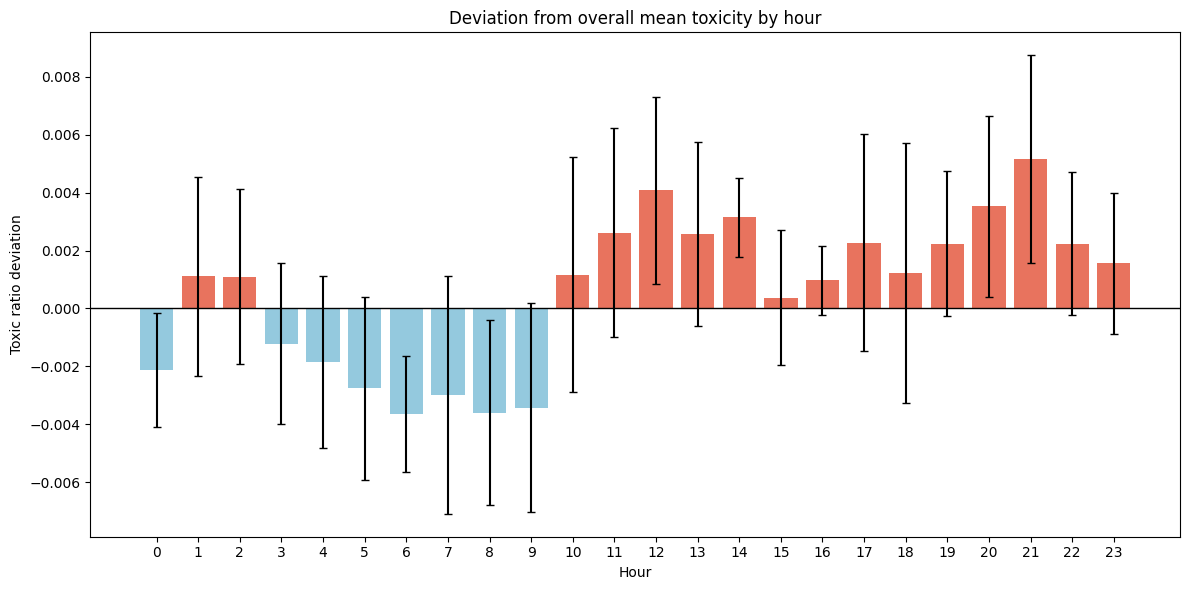

In [11]:
# diffrernce
hour_stats['diff_from_mean'] = hour_stats['mean'] - overall_toxic_ratio

# red if more than avg, blue if less than avg
colors = ['tomato' if diff > 0 else 'skyblue' for diff in hour_stats['diff_from_mean']]

plt.figure(figsize=(12,6))
ax = sns.barplot(data=hour_stats, x='hour', y='diff_from_mean', palette=colors)
plt.axhline(y=0, color='black', linewidth=1)
plt.errorbar(x=range(24), y=hour_stats['diff_from_mean'], yerr=hour_stats['ci'], fmt='none', c='black', capsize=3)

plt.title('Deviation from overall mean toxicity by hour')
plt.xlabel('Hour')
plt.ylabel('Toxic ratio deviation')
plt.tight_layout()
plt.show()

Conclusions by hour:

- During the day, toxicity also changes (see numbers later), but the effect is weaker than for days of the week.  
- There is an **increase in toxicity in the evening and night hours** (around 21:00–23:00) and a **decline in the morning** (6:00–9:00).  
- This means that **late evening (21:00) is significantly more toxic than early morning**, which may indicate a change in the nature of communication depending on the time of day.  
- Despite the modest effect sizes, the overall trend is visible and is consistent with the expectation that the emotional tone of messages varies throughout the day.

### Agregate by day AND hour

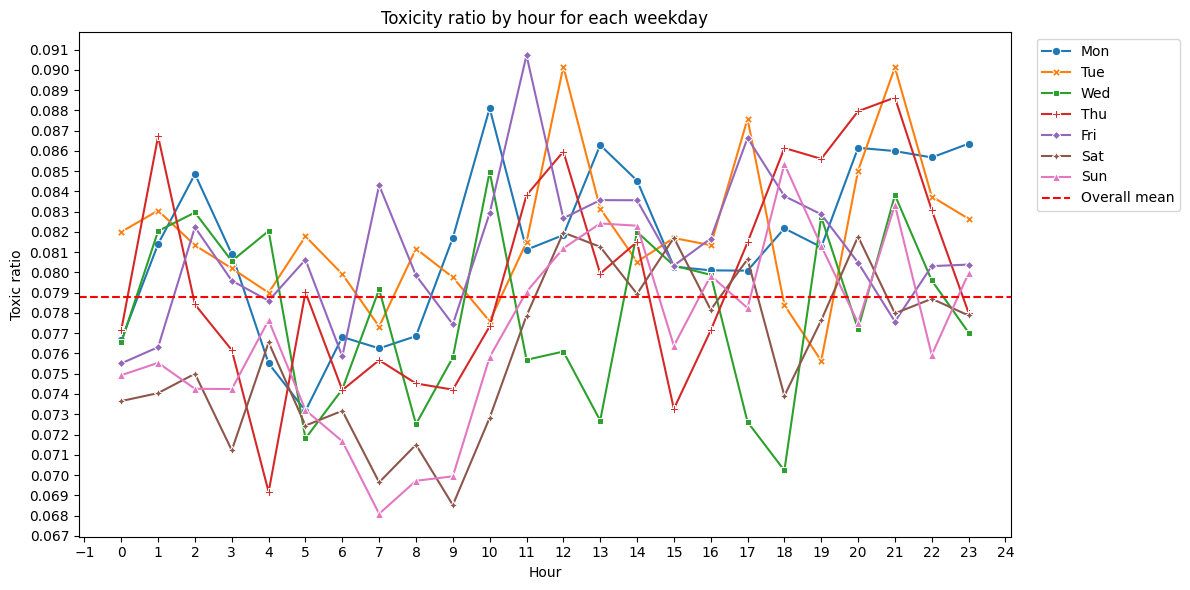

In [12]:
day_order = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
time_pd['day_name'] = pd.Categorical(time_pd['day_name'], categories=day_order, ordered=True)

plt.figure(figsize=(12,6))
sns.lineplot(
    data=time_pd,
    x='hour',
    y='toxic_ratio',
    hue='day_name',
    style='day_name',
    markers=True,
    dashes=False,
    palette='tab10'
)


plt.gca().yaxis.set_major_locator(MultipleLocator(0.001))
plt.gca().xaxis.set_major_locator(MultipleLocator(1))

plt.axhline(y=overall_toxic_ratio, color='red', linestyle='--', label='Overall mean')
plt.title('Toxicity ratio by hour for each weekday')
plt.xlabel('Hour')
plt.ylabel('Toxic ratio')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/1016112422.py:1: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = time_pd.pivot_table(


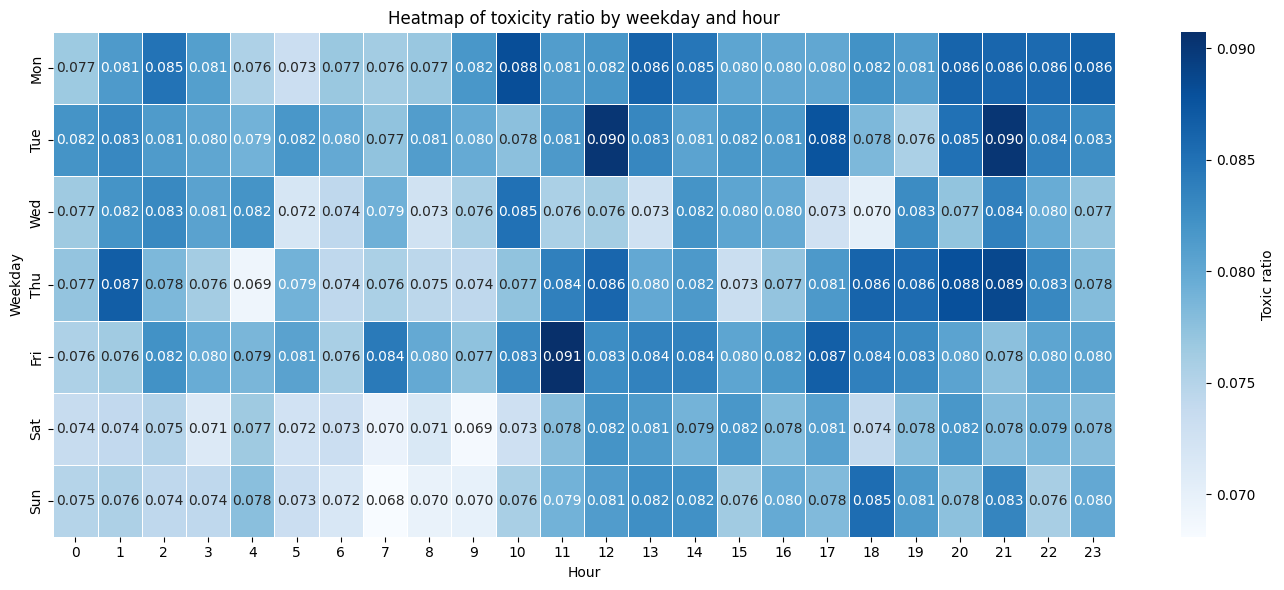

In [13]:
pivot = time_pd.pivot_table(
    index='day_name',
    columns='hour',
    values='toxic_ratio',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot,
    cmap='Blues',
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Toxic ratio'}
)
plt.title('Heatmap of toxicity ratio by weekday and hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.tight_layout()
plt.show()

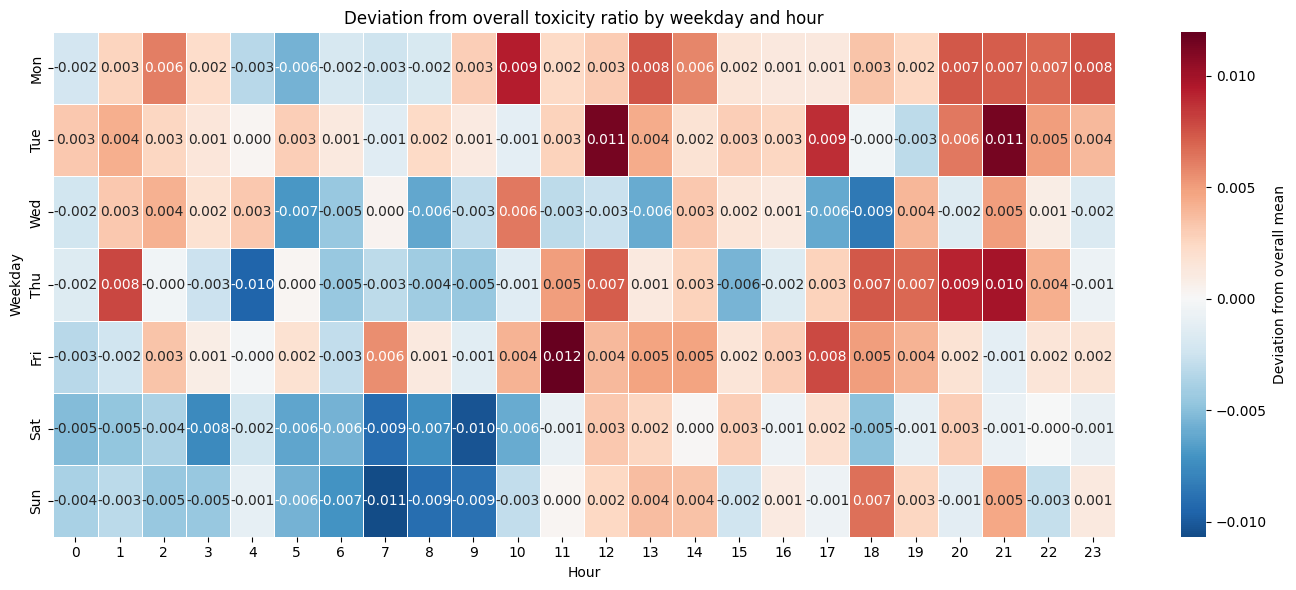

In [14]:
pivot_diff = pivot - overall_toxic_ratio

plt.figure(figsize=(14,6))
sns.heatmap(
    pivot_diff,
    cmap='RdBu_r',
    center=0,
    annot=True,
    fmt='.3f',
    linewidths=0.5,
    cbar_kws={'label': 'Deviation from overall mean'}
)
plt.title('Deviation from overall toxicity ratio by weekday and hour')
plt.xlabel('Hour')
plt.ylabel('Weekday')
plt.tight_layout()
plt.show()

Joint analysis day × hour:

- The line graph shows that **curves for different days of the week retain a similar shape**, but are shifted vertically: Tuesday and Friday are usually higher, and Saturday is lower than the rest.  
- The heat map confirms that the **hottest zones** occur in the late hours (20-23) on weekdays, especially on Tuesday.  
- The least toxic cells are the morning and afternoon hours of Saturday and Sunday.  
- The deviation map (red-blue) allows you to immediately notice that on Saturday almost all hours the toxicity is below average, and on Tuesday it is higher, which is consistent with previous findings.  
- Thus, the combined influence of day of week and hour supports the hypothesis of the presence of temporal patterns of toxicity.

### Statistical significance test (ANOVA)

Let's compare the average toxicity by day of the week. If p-value < 0.05, the differences are statistically significant.

In [15]:
# by days
day_groups = [time_pd[time_pd['weekday']==d]['toxic_ratio'] for d in range(7)]
f_stat, p_value = stats.f_oneway(*day_groups)
print(f"ANOVA (weekday): F={f_stat:.4f}, p={p_value:.4f}")

# by hours
hour_groups = [time_pd[time_pd['hour']==h]['toxic_ratio'] for h in range(24)]
f_stat_h, p_val_h = stats.f_oneway(*hour_groups)
print(f"ANOVA (hour): F={f_stat_h:.4f}, p={p_val_h:.4f}")

ANOVA (weekday): F=7.1573, p=0.0000
ANOVA (hour): F=2.7801, p=0.0001


### Tukey HSD for days

ANOVA confirms that both day of week and hour have a significant effect on the proportion of toxic tweets (p < 0.0001). But ANOVA only says “there are differences,” without specifying between which days or hours. To understand in more detail, let’s conduct a post-hoc Tukey test (Tukey HSD) - it compares all groups in pairs and shows exactly where the difference is significant.

In [16]:
tukey_days = pairwise_tukeyhsd(
    endog=time_pd['toxic_ratio'],   # what we are comparing
    groups=time_pd['day_name'],     # group by day
    alpha=0.05
)

print("Tukey HSD results for weekdays:")
print(tukey_days)

Tukey HSD results for weekdays:
Multiple Comparison of Means - Tukey HSD, FWER=0.05 
group1 group2 meandiff p-adj   lower   upper  reject
----------------------------------------------------
   Fri    Mon   0.0003    1.0 -0.0034  0.0039  False
   Fri    Sat   -0.005 0.0011 -0.0087 -0.0014   True
   Fri    Sun  -0.0042 0.0135 -0.0078 -0.0005   True
   Fri    Thu  -0.0014 0.9213  -0.005  0.0023  False
   Fri    Tue   0.0007 0.9974 -0.0029  0.0043  False
   Fri    Wed  -0.0031   0.14 -0.0068  0.0005  False
   Mon    Sat  -0.0053 0.0005 -0.0089 -0.0017   True
   Mon    Sun  -0.0044 0.0066 -0.0081 -0.0008   True
   Mon    Thu  -0.0016 0.8344 -0.0053   0.002  False
   Mon    Tue   0.0004 0.9998 -0.0032  0.0041  False
   Mon    Wed  -0.0034 0.0834  -0.007  0.0002  False
   Sat    Sun   0.0009 0.9916 -0.0028  0.0045  False
   Sat    Thu   0.0037 0.0457     0.0  0.0073   True
   Sat    Tue   0.0057 0.0001  0.0021  0.0094   True
   Sat    Wed   0.0019 0.7072 -0.0017  0.0055  False
   Sun    Thu 

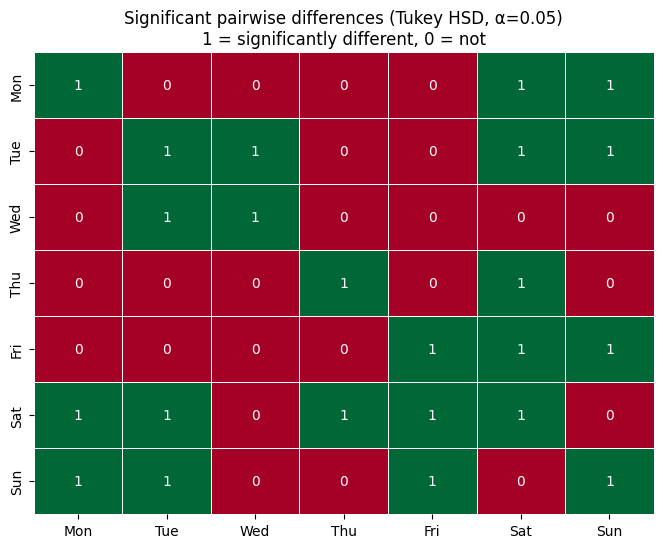

In [17]:
results_df = pd.DataFrame(
    data=tukey_days._results_table.data[1:],
    columns=tukey_days._results_table.data[0]
)

# day * day
days_list = day_order
matrix = pd.DataFrame(np.eye(len(days_list)), index=days_list, columns=days_list)

# 1 if p<0/05
for _, row in results_df.iterrows():
    g1, g2 = row['group1'], row['group2']
    p = float(row['p-adj'])
    if p < 0.05:
        matrix.loc[g1, g2] = 1
        matrix.loc[g2, g1] = 1
    else:
        matrix.loc[g1, g2] = 0
        matrix.loc[g2, g1] = 0

plt.figure(figsize=(8,6))
sns.heatmap(matrix, annot=True, cmap='RdYlGn', cbar=False, linewidths=0.5)
plt.title('Significant pairwise differences (Tukey HSD, α=0.05)\n1 = significantly different, 0 = not')
plt.show()

Lets again compare confidence intervals: if the intervals of two days do not overlap, the difference is significant.

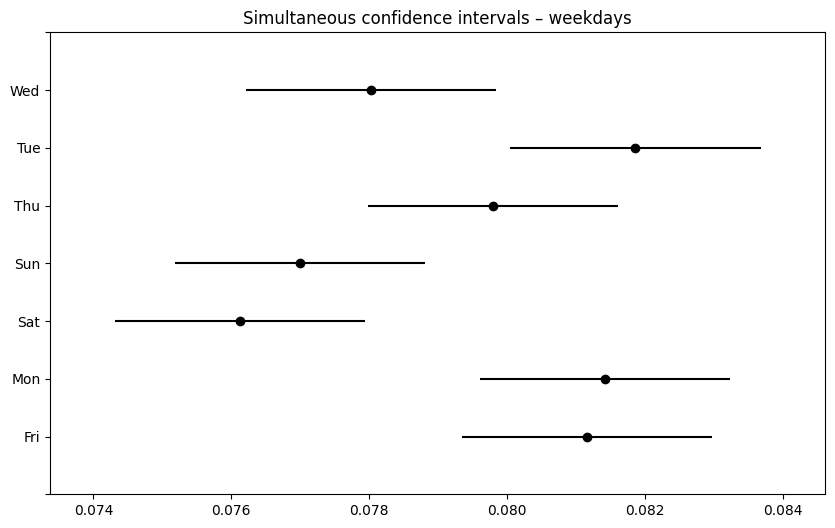

In [18]:
tukey_days.plot_simultaneous()
plt.title('Simultaneous confidence intervals – weekdays')
plt.show()

### Tukey HSD for hours

In [19]:
tukey_hours = pairwise_tukeyhsd(
    endog=time_pd['toxic_ratio'],
    groups=time_pd['hour'],
    alpha=0.05
)

print("Tukey HSD results for hours:")
print(tukey_hours)

Tukey HSD results for hours:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     0      1   0.0032 0.9989  -0.005 0.0115  False
     0      2   0.0032 0.9989  -0.005 0.0115  False
     0      3   0.0009    1.0 -0.0074 0.0092  False
     0      4   0.0003    1.0  -0.008 0.0086  False
     0      5  -0.0006    1.0 -0.0089 0.0076  False
     0      6  -0.0015    1.0 -0.0098 0.0068  False
     0      7  -0.0009    1.0 -0.0091 0.0074  False
     0      8  -0.0015    1.0 -0.0098 0.0068  False
     0      9  -0.0013    1.0 -0.0096  0.007  False
     0     10   0.0033 0.9985  -0.005 0.0116  False
     0     11   0.0048 0.8952 -0.0035  0.013  False
     0     12   0.0062 0.4593 -0.0021 0.0145  False
     0     13   0.0047 0.9057 -0.0036  0.013  False
     0     14   0.0053 0.7685  -0.003 0.0136  False
     0     15   0.0025    1.0 -0.0058 0.0108  False
     0     16   0.0031 0.9994 -0.00

In [20]:
# compact table
results_hours_df = pd.DataFrame(
    data=tukey_hours._results_table.data[1:],
    columns=tukey_hours._results_table.data[0]
)
results_hours_df['meandiff'] = results_hours_df['meandiff'].astype(float)
results_hours_df['p-adj'] = results_hours_df['p-adj'].astype(float)

# top 10 pair with most difference, p<0.05
top_hours = results_hours_df[results_hours_df['p-adj'] < 0.05].copy()
top_hours['abs_diff'] = np.abs(top_hours['meandiff'])
top_hours = top_hours.sort_values('abs_diff', ascending=False).head(10)

print("Top most different hour pairs (significant):")
print(top_hours[['group1','group2','meandiff','p-adj']])

Top most different hour pairs (significant):
     group1  group2  meandiff   p-adj
137       6      21    0.0088  0.0235
168       8      21    0.0088  0.0250
182       9      21    0.0086  0.0325


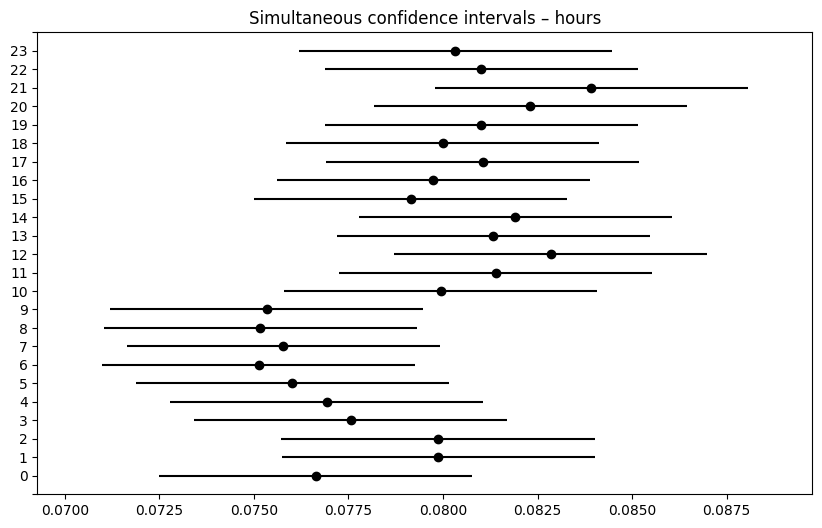

In [21]:
tukey_hours.plot_simultaneous()
plt.title('Simultaneous confidence intervals – hours')
plt.show()


- Most Tukey pairwise comparisons did not reach significance, but three pairs (6–21, 8–21, 9–21) were statistically significantly different.  

Statistical confirmation:

- One-way analysis of variance (ANOVA) showed that **day of the week significantly affects the average proportion of toxic tweets** (F=7.16, p≈0.0000).  
- Tukey's post-hoc test identified specific pairs with significant differences:  
  - **Saturday is significantly less toxic** than Monday, Tuesday, Thursday, Friday and Sunday.  
  - **Tuesday is significantly more toxic** than Saturday, Sunday and Wednesday.  
  - **Sunday** is also significantly less toxic than Tuesday.  
- For hours, ANOVA is also significant (F=2.78, p=0.0001), but **pairwise differences were found only between 21:00 and morning hours (6, 8, 9)**.  
- Consequently, **the daily rhythm of toxicity is weaker than the weekly one**, but is present, especially the “late evening - morning” contrast.  
- These results allow us to reject the null hypothesis of the absence of time effects and confirm the first hypothesis of the project.

## Hypothesis 2: Is toxicity and sentiment connected?

Plan:
- make scatter plot `avg_toxicity` vs `avg_sentiment_pos_ratio` by users
- calculate Pearson and Spearman
- ?


Results:
- Statistically there are differences (due to the gigantic size of the data), but the real magnitude of the effect is negligible
- Average toxicity practically does not depend on whether the person is positive, negative or mixed
- interesting detail: users with mixed emotions are slightly more likely to have non-zero toxicity, but its level is still extremely low
- **Toxicity and general sentiment are almost independent things**

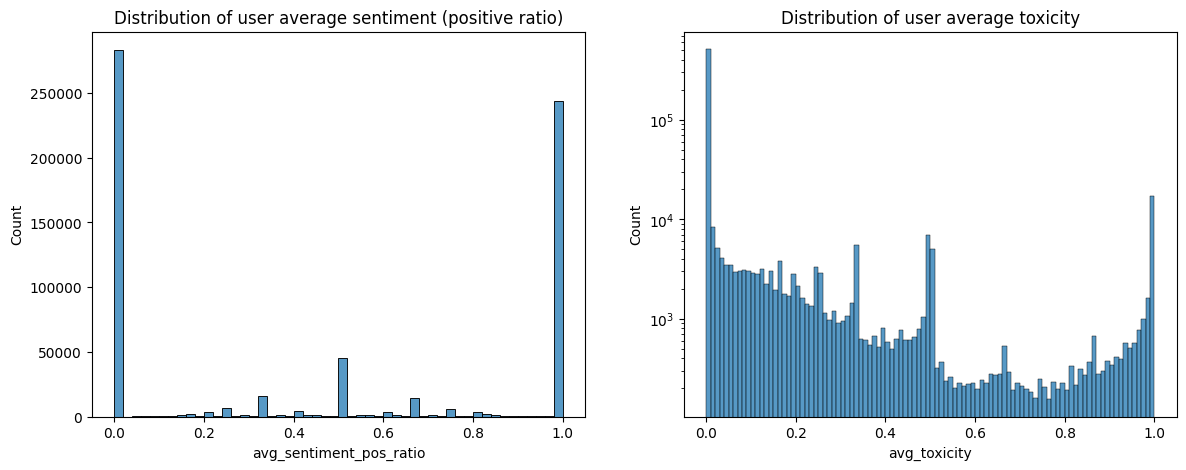

In [22]:
# Quick sanity check
fig, axes = plt.subplots(1, 2, figsize=(14,5))
sns.histplot(user_pd['avg_sentiment_pos_ratio'], bins=50, ax=axes[0])
axes[0].set_title('Distribution of user average sentiment (positive ratio)')
sns.histplot(user_pd['avg_toxicity'], bins=100, ax=axes[1])
axes[1].set_title('Distribution of user average toxicity')
axes[1].set_yscale('log')
plt.show()

As we can see, most users are eather always negative or always positive. Toxicity is right skewed (many near zero values)

### Check global correlation

In [23]:
# pearson and spearman
r_pearson, p_pearson = stats.pearsonr(user_pd['avg_sentiment_pos_ratio'], user_pd['avg_toxicity'])
r_spearman, p_spearman = stats.spearmanr(user_pd['avg_sentiment_pos_ratio'], user_pd['avg_toxicity'])
print(f"Pearson r = {r_pearson:.4f}, p = {p_pearson:.2e}")
print(f"Spearman r = {r_spearman:.4f}, p = {p_spearman:.2e}")

Pearson r = 0.0187, p = 3.09e-52
Spearman r = 0.0386, p = 4.11e-216


In [24]:
# Filter users with >= 10 tweets
active_users = user_pd[user_pd['tweet_count'] >= 10]
r_act, p_act = stats.pearsonr(active_users['avg_sentiment_pos_ratio'], active_users['avg_toxicity'])
print(f"Active users (>=10 tweets): r = {r_act:.4f}, p = {p_act:.2e}")
print(f"Number of active users: {len(active_users)}")

Active users (>=10 tweets): r = 0.0424, p = 4.13e-10
Number of active users: 21752


**Pearson** 

Measure linear connection btw 2 variables: 
- the closer to +1, the stronger the positive relationship
- the closer to –1, the stronger the negative
- 0 means no linear connection.
In our case it is near positive, but near 0, so we can neglet it

**Spearman**

Measure monotonic connections (not only linear)

In our case it is still near 0, so even if it is non-linearly connected, we can neglet that connection

**P values**
They tell us that that correlations are not random (statistically meaningfull)

**Overall**
More positive users are a bit less toxic and vice versa, but that connection is very weak -> toxicity and sentiment are almost independent
The correlation among active users is slightly stronger but still very weak. So the weak relationship is not just due to noisy estimates for users with few tweets.

/usr/local/lib/python3.12/dist-packages/statsmodels/nonparametric/smoothers_lowess.py:226: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


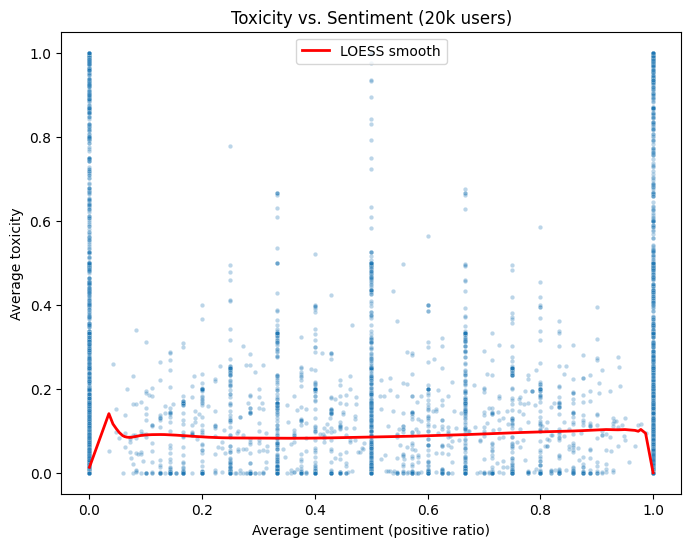

In [25]:
# visualise on subset
sample = user_pd.sample(20000, random_state=42)
plt.figure(figsize=(8,6))
sns.scatterplot(data=sample, x='avg_sentiment_pos_ratio', y='avg_toxicity', alpha=0.3, s=10)
# Add a LOESS smooth to see any nonlinear trend
from statsmodels.nonparametric.smoothers_lowess import lowess
# lowess expects 1‑D arrays, filter out possible NaNs (none here)
xy = sample[['avg_sentiment_pos_ratio','avg_toxicity']].dropna()
smoothed = lowess(xy['avg_toxicity'], xy['avg_sentiment_pos_ratio'], frac=0.3, return_sorted=True)
plt.plot(smoothed[:,0], smoothed[:,1], color='red', linewidth=2, label='LOESS smooth')
plt.xlabel('Average sentiment (positive ratio)')
plt.ylabel('Average toxicity')
plt.title('Toxicity vs. Sentiment (20k users)')
plt.legend()
plt.show()

The LOESS curve stays nearly flat around **0.10**, with only a tiny bump to **~0.15** in the beginning.  
No clear upward or downward trend is visible – confirming that sentiment and toxicity are barely related.

Are users who are “always positive” less toxic? 

sentiment_quartile
Q1: Always negative (0)        283345
Q4: Always positive (1)        243645
Q2: Mostly negative (0–0.5)     89290
Q3: Mostly positive (0.5–1)     42433
Name: count, dtype: int64


/tmp/ipykernel_16/3275108929.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=user_pd, x='sentiment_quartile', y='avg_toxicity', palette='coolwarm')


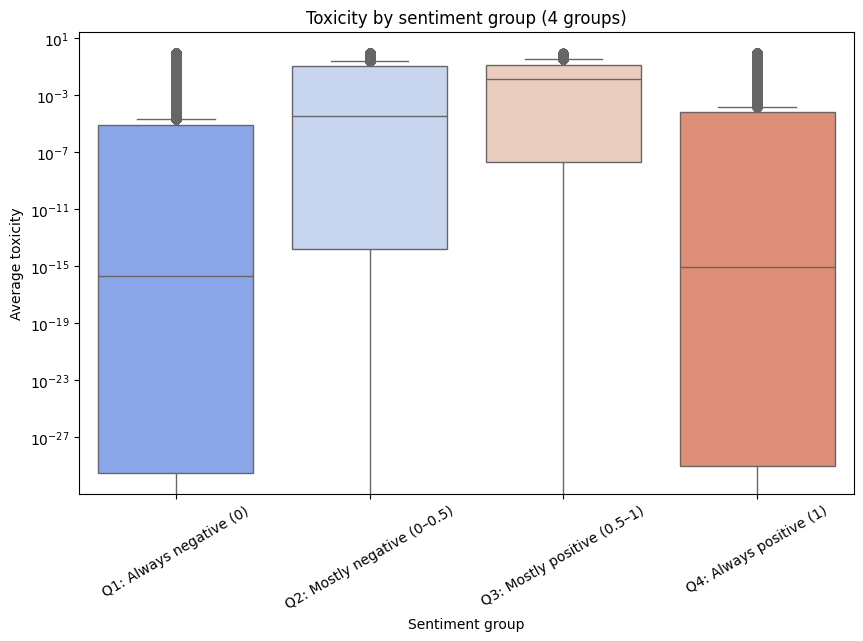

In [26]:
bins = [-0.001, 0.001, 0.5, 0.999, 1.001]
labels = ['Q1: Always negative (0)', 
          'Q2: Mostly negative (0–0.5)', 
          'Q3: Mostly positive (0.5–1)', 
          'Q4: Always positive (1)']

user_pd['sentiment_quartile'] = pd.cut(
    user_pd['avg_sentiment_pos_ratio'], 
    bins=bins, 
    labels=labels, 
    include_lowest=True
)

print(user_pd['sentiment_quartile'].value_counts())

plt.figure(figsize=(10,6))
sns.boxplot(data=user_pd, x='sentiment_quartile', y='avg_toxicity', palette='coolwarm')
plt.yscale('log')
plt.title('Toxicity by sentiment group (4 groups)')
plt.xlabel('Sentiment group')
plt.ylabel('Average toxicity')
plt.xticks(rotation=30)
plt.show()

In [27]:
# statistical test Kruskal-Wallis
groups = [user_pd[user_pd['sentiment_quartile'] == q]['avg_toxicity'] for q in user_pd['sentiment_quartile'].cat.categories]
H, p = stats.kruskal(*groups)
print(f"Kruskal-Wallis H = {H:.1f}, p = {p:.2e}")

Kruskal-Wallis H = 56980.9, p = 0.00e+00


Group sizes & visual pattern:
- **Q1 (Always neg.)**: 283k – largest, all-negative users.  
- **Q4 (Always pos.)**: 244k – second, all-positive users.  
- **Q2 (Mostly neg.)**: 89k.  
- **Q3 (Mostly pos.)**: 42k – smallest group, but highest median toxicity on the boxplot.

**Kruskal-Wallis:** H = 56981, p ≈ 0.0000 → statistically significant differences exist, but the effect size is tiny (mean differences << 0.001).


/tmp/ipykernel_16/355986796.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = user_pd.groupby('sentiment_quartile')['avg_toxicity'].agg(['mean', 'std', 'count'])
/tmp/ipykernel_16/355986796.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=group_stats, x='sentiment_quartile', y='mean', palette='coolwarm')


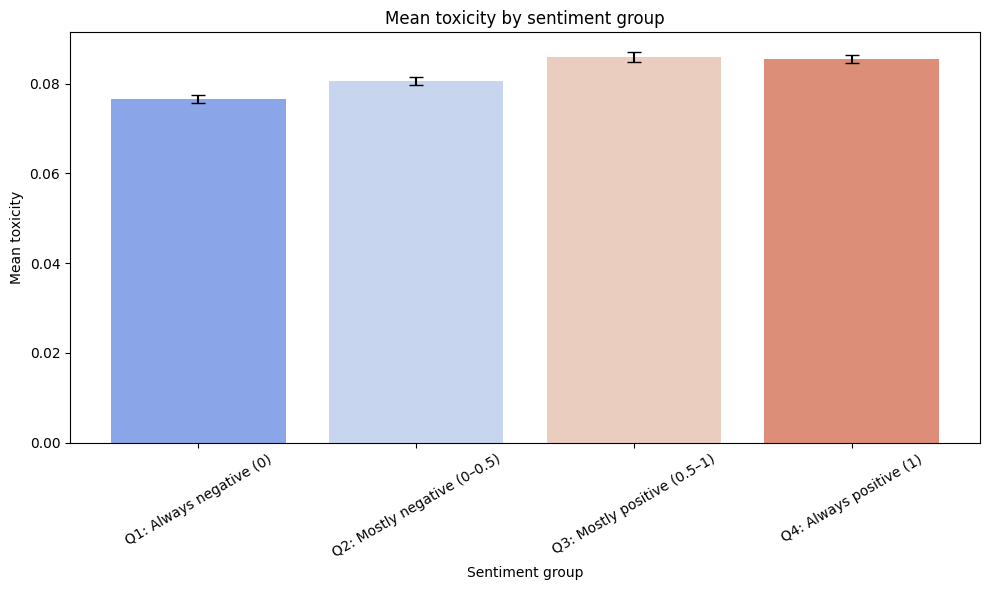

            sentiment_quartile      mean        ci
0      Q1: Always negative (0)  0.076582  0.000845
1  Q2: Mostly negative (0–0.5)  0.080597  0.000962
2  Q3: Mostly positive (0.5–1)  0.085919  0.001141
3      Q4: Always positive (1)  0.085483  0.000947


In [28]:
# compare trust intervals
group_stats = user_pd.groupby('sentiment_quartile')['avg_toxicity'].agg(['mean', 'std', 'count'])
group_stats['ci'] = 1.96 * group_stats['std'] / np.sqrt(group_stats['count'])
group_stats = group_stats.reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=group_stats, x='sentiment_quartile', y='mean', palette='coolwarm')
plt.errorbar(x=range(4), y=group_stats['mean'], yerr=group_stats['ci'], fmt='none', c='black', capsize=5)
plt.title('Mean toxicity by sentiment group')
plt.xlabel('Sentiment group')
plt.ylabel('Mean toxicity')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

print(group_stats[['sentiment_quartile', 'mean', 'ci']])

Average toxicity level for users in each group

All confidence intervals are very narrow (±0.001), differences between groups are extremely small (less than 0.01). 

*Conclusion:* Although some groups are formally different, in practice the toxicity is almost the same for all.

In [29]:
dunn_data = user_pd[['avg_toxicity', 'sentiment_quartile']].copy()

dunn_results = sp.posthoc_dunn(dunn_data, val_col='avg_toxicity', group_col='sentiment_quartile', p_adjust='bonferroni')
print("Dunn's test p-values (Bonferroni corrected):")
print(dunn_results)

Dunn's test p-values (Bonferroni corrected):
                             Q1: Always negative (0)  \
Q1: Always negative (0)                 1.000000e+00   
Q2: Mostly negative (0–0.5)             0.000000e+00   
Q3: Mostly positive (0.5–1)             0.000000e+00   
Q4: Always positive (1)                 4.932412e-71   

                             Q2: Mostly negative (0–0.5)  \
Q1: Always negative (0)                              0.0   
Q2: Mostly negative (0–0.5)                          1.0   
Q3: Mostly positive (0.5–1)                          0.0   
Q4: Always positive (1)                              0.0   

                             Q3: Mostly positive (0.5–1)  \
Q1: Always negative (0)                              0.0   
Q2: Mostly negative (0–0.5)                          0.0   
Q3: Mostly positive (0.5–1)                          1.0   
Q4: Always positive (1)                              0.0   

                             Q4: Always positive (1)  
Q1: Always negati

Tests which specific groups the difference is statistically significant between

Almost all p‑values approx 0.0000 – i.e. the test screams that the groups are different. 
*Conclusion:* this is a consequence of a huge sample (hundreds of thousands of users). Even a microscopic difference of 0.001 becomes statistically significant, but has no practical meaning.

In [30]:
median_tox = user_pd['avg_toxicity'].median()
print(f"Median toxicity (all users): {median_tox:.6f}")

tox_above_median = user_pd.groupby('sentiment_quartile')['avg_toxicity'].apply(lambda x: (x > median_tox).mean()).reset_index(name='fraction_above_median')
print(tox_above_median)

Median toxicity (all users): 0.000000
            sentiment_quartile  fraction_above_median
0      Q1: Always negative (0)               0.422990
1  Q2: Mostly negative (0–0.5)               0.731269
2  Q3: Mostly positive (0.5–1)               0.851578
3      Q4: Always positive (1)               0.443572


/tmp/ipykernel_16/1034683765.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tox_above_median = user_pd.groupby('sentiment_quartile')['avg_toxicity'].apply(lambda x: (x > median_tox).mean()).reset_index(name='fraction_above_median')


We took the overall median toxicity (0.0 because most have zero toxicity) and counted how many users in each group had toxicity >0

Conclusion: users with mixed emotions (Q2, Q3) are much more likely to have at least some non-zero toxicity than “purely negative” or “purely positive”. This hints that toxicity is more common in people with mood swings, but the level of toxicity itself is still very low